####Text To Image Generation
####Google Gemini Integration using Langchain API
<!-- https://reference.langchain.com/python/langchain-google-genai/chat_models/ChatGoogleGenerativeAI?_gl=1*b2b0al*_gcl_au*MTQyODM2MzA3Ni4xNzc4NDMzODM2*_ga*MTc2NjU1ODg4Ni4xNzc4NDMzODM4*_ga_47WX3HKKY2*czE3Nzk1Mzg3NTMkbzE0JGcxJHQxNzc5NTM4ODkxJGo2MCRsMCRoMA..

https://docs.langchain.com/oss/python/integrations/chat/google_generative_ai?_gl=1*tzk6mc*_gcl_au*MTQyODM2MzA3Ni4xNzc4NDMzODM2*_ga*MTc2NjU1ODg4Ni4xNzc4NDMzODM4*_ga_47WX3HKKY2*czE3Nzk1Mzg3NTMkbzE0JGcxJHQxNzc5NTM4OTAyJGo0OSRsMCRoMA..#image-generation -->

In [17]:
import os
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import AIMessage
import base64
from IPython.display import Image, display
import requests  # ← add this line


Google_API_Token_Key=os.getenv("GOOGLE_API_KEY")
if(Google_API_Token_Key is None):
    raise ValueError("GOOGLE_API_KEY environment variable not set.")
else:
 key=   os.environ["GOOGLE_API_KEY"] = Google_API_Token_Key;

# # Direct API test
# url = f"https://generativelanguage.googleapis.com/v1beta/models?key={key}"
# response = requests.get(url)

# print(f"\nAPI Test Status: {response.status_code}")
# if response.status_code == 200:
#     print("✅ Key is VALID")
# else:
#     print(f"❌ Key INVALID: {response.json()}")

model=ChatGoogleGenerativeAI(model="gemini-2.5-flash-image",google_api_key=key)

response=model.invoke("Generative a dog Image",generation_config={
        "response_modalities": ["TEXT", "IMAGE"] 
    })

def get_generate_image(response, AIMessage)->None:
    image_block = next(
        block
        for block in response.content
        if isinstance(block, dict) and block.get("image_url")
    )
    return image_block["image_url"].get("url").split(",")[-1]

image_base64 = get_generate_image(response)
display(Image(data=base64.b64decode(image_base64), width=300))

model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash-image",
    image_config={"aspect_ratio": "16:9"},
)

   


ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash-image' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.5-flash-preview-image\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.5-flash-preview-image\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.5-flash-preview-image\nPlease retry in 11.797251359s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'descript

#Text To Image With hugging Model provider Using Lanchain Framework


Method 1: Direct Tool Invocation
Generating image for: 'Forest Image with water stream'...
✅ Image saved to: generated_image.png
Result: generated_image.png


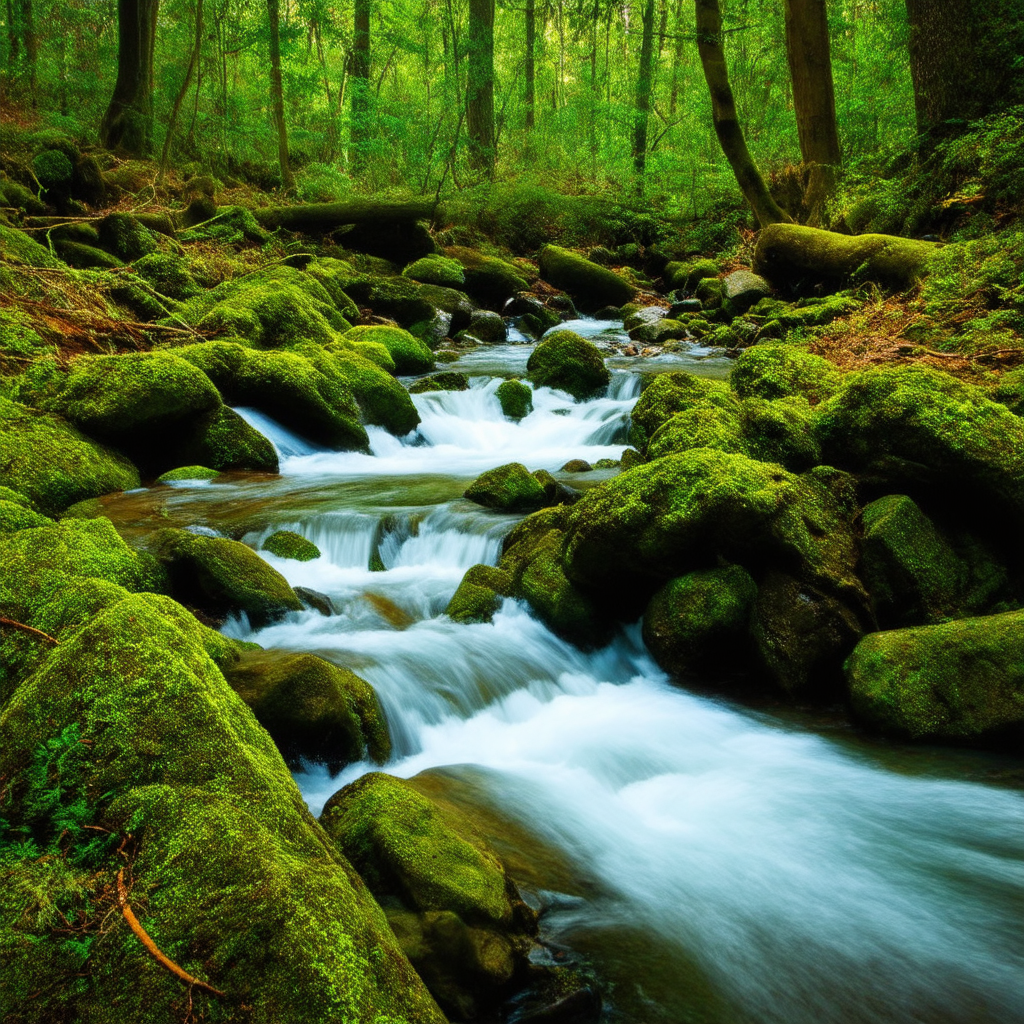

In [3]:
import os
from dotenv import load_dotenv
from huggingface_hub import InferenceClient
from langchain.tools import tool
from IPython.display import Image as IPImage, display

# ============================================
# Step 1: Load environment variables
# ============================================
load_dotenv(override=True)

HF_TOKEN = os.getenv("HUGGINGFACEHUB_API_TOKEN")
if not HF_TOKEN:
    raise ValueError("❌ HUGGINGFACEHUB_API_TOKEN not found in .env")


# ============================================
# Step 2: Create the LangChain Tool
# ============================================
@tool
def generate_image(prompt: str) -> str:
    """
    Generates an image from a text prompt using HuggingFace Stable Diffusion.    
    Args:
        prompt: Text description of the image to generate        
    Returns:
        Path to the saved image file
    """
    try:
        # Initialize HuggingFace client
        client = InferenceClient(token=HF_TOKEN)        
        print(f"Generating image for: '{prompt}'...")        
        # Generate image
        image = client.text_to_image(
            prompt=prompt,
            model="stabilityai/stable-diffusion-3-medium"
        )        
        # Save image
        output_path = "generated_image.png"
        image.save(output_path)        
        print(f"✅ Image saved to: {output_path}")
        return output_path        
    except Exception as e:
        error_msg = f"Image generation failed: {str(e)}"
        print(error_msg)
        return error_msg


# ============================================
# Step 3: Use the Tool (Direct Invocation)
# ============================================
if __name__ == "__main__":
    
    # Method 1: Direct invocation using .invoke()
    print("\n" + "="*50)
    print("Method 1: Direct Tool Invocation")
    print("="*50)
    
    result = generate_image.invoke("Forest Image with water stream")
    print(f"Result: {result}")
    
    # Display image in Jupyter Notebook
    if os.path.exists(result):
        display(IPImage(filename=result, width=400))

##Text To Image Generation  OpenRouter Model Provider using Langchain
    <!-- 1.Open Router Doesn't have direct or seperate Image API for Image Generation.
    2.Image Generation Works through chat completion endpoint and need to set the Modalities to ["image","text"] for models.(Treat like chat call but Request image in output). 
    3.Image generation Models: https://openrouter.ai/collections/image-models
    4.Image generation MultiModal : https://openrouter.ai/docs/guides/overview/multimodal/image-generation
    5.langchain-openai — OpenRouter uses OpenAI-compatible API
    6.LiteLLM Support OpenRouter image generation transforms image generation requests to OpenRouter's Chat completion format.  https://docs.litellm.ai/docs/providers/openrouter
    7.There's no dedicated LangChain class for it; you use ChatOpenAI with OpenRouter's base_url and set the modalities parameter for image output. -->

    <!-- LangChain's ChatOpenAI doesn't expose the modalities and image_config parameters natively, and the response's images field isn't part of LangChain's standard message schema. So we pass these via extra_body / model_kwargs and extract the image from the raw response. -->


In [ ]:
import os
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from IPython.display import Image, display

load_dotenv()
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
if not OPENROUTER_API_KEY:
    raise ValueError("OPENROUTER_API_KEY not found in .env")

# ============================================
# Step 2: Configure ChatOpenAI for OpenRouter
# The base_url Magic tells LangChain to route through OpenRouter, and extra_body configures the image generation parameters.

# Normal ChatOpenAI:
    #ChatOpenAI → api.openai.com → OpenAI models
    
#With base_url changed:
    #ChatOpenAI → openrouter.ai → OpenRouter models
# ============================================
model = ChatOpenAI(
    model="google/gemini-2.5-flash-image",   # image-capable model
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1",  # ← OpenRouter endpoint
    extra_body={
        "modalities": ["image"],       # ← request image output
        "image_config": {
            "aspect_ratio": "16:9",
            "image_size": "2K"
        }
    }
)

# ============================================
# Step 3: Invoke with a prompt
# ============================================
response = model.invoke([
    HumanMessage(content="Generate a beautiful sunset over mountains, photorealistic")
])
# ============================================
# Step 4: Extract the image from raw response
# ============================================
def save_openrouter_image(response, output_path="output.png"):
    """Extract base64 image from OpenRouter response and save it."""
    
    # LangChain doesn't know where to put it, so it dumps it into one of two places:  image lives in additional_kwargs or response_metadata depending on version
    images = response.additional_kwargs.get("images") # where LangChain stores extra non-standard data
    
    if not images:
        # Fallback: check response_metadata
        images = response.response_metadata.get("images") #fallback location (varies by version)
    
    if not images:
        print("No image in response. Text content:")
        print(response.content)
        return None
    
    # Extract base64 data URL
    image_url = images[0]["image_url"]["url"]  # data:image/png;base64,....
    base64_data = image_url.split(",", 1)[1]
    
    # Decode and save
    with open(output_path, "wb") as f:
        f.write(base64.b64decode(base64_data))
    
    print(f"Image saved to: {output_path}")
    return output_path

path = save_openrouter_image(response)
if path:
    display(IPImage(filename=path, width=500))




❌ No image in response. Text content:
Here's a beautiful sunset over mountains for you! 


<!-- ============================================
 #Above code OpenROuter Returns Image but Lanchain Drops the image and only returns text response. 

# Response from Above Code
    # ❌ No image in response. Text content:
    # Here's a beautiful sunset over mountains for you!
#Why this Happend?
        OpenRouter returned:
        {
         "content": "Here's a beautiful sunset...",   ← LangChain KEPT this
         "images": [{ "image_url": {...} }]           ← LangChain DROPPED this
         }

         ChatOpenAI parses only the fields it knows about (text).
         The non-standard "images" field gets discarded.
        -->
<!-- #Solution for this is to 2- Ways
  1.use OpenAI SDK
  2.Use Raw requests (Most Reliable.) -->

In [ ]:
import os
import base64
import requests
from dotenv import load_dotenv
from IPython.display import Image as IPImage, display

load_dotenv(override=True)

url = "https://openrouter.ai/api/v1/chat/completions"
headers = {
    "Authorization": f"Bearer {os.getenv('OPENROUTER_API_KEY')}",
    "Content-Type": "application/json"
}
payload = {
    "model": "google/gemini-2.5-flash-image",
    "messages": [
        {"role": "user", "content": "A beautiful sunset over mountains, photorealistic"}
    ],
    "modalities": ["image"],
    "image_config": {"aspect_ratio": "16:9", "image_size": "2K"}
}

response = requests.post(url, headers=headers, json=payload)
result = response.json()

#This should have images in output keys.
print("="*50)
print("TOP-LEVEL KEYS:", list(result.keys()))
print("="*50)

print("Status Code:", response.status_code)
print("\n🔴 ERROR DETAILS:")


# Inspect the structure first (helpful for debugging)
# message = result["choices"][0]["message"]
# print("Keys in message:", message.keys())   # see where image is

# if message.get("images"):
#     base64_data = message["images"][0]["image_url"]["url"].split(",", 1)[1]
#     with open("sunset.png", "wb") as f:
#         f.write(base64.b64decode(base64_data))
#     print("✅ Image saved: sunset.png")
#     display(IPImage(filename="sunset.png", width=500))
# else:
#     print("❌ No 'images' key. Full message:")
#     print(message)

TOP-LEVEL KEYS: ['error', 'user_id']
Status Code: 402

🔴 ERROR DETAILS:
